# MSCS 634 – Data Mining
### Lab Assignment 3: Clustering Analysis with K-Means and K-Medoids

**Name:** [Your Name Here]
**Course:** MSCS 634 – Data Mining
**Assignment:** Lab 3 – Clustering with K-Means and K-Medoids (Wine Dataset)

---

This notebook explores clustering techniques using the **Wine Dataset** from
`sklearn`. Both **K-Means** and **K-Medoids** are applied to the standardized
data, evaluated using the **Silhouette Score** and **Adjusted Rand Index
(ARI)**, and compared visually and analytically.

## Step 1: Load and Prepare the Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


### Load the Wine dataset

In [2]:
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
target_names = wine.target_names

df = pd.DataFrame(X, columns=feature_names)
df["target"] = y

print("Dataset shape:", X.shape)
print("Number of features:", len(feature_names))
print("Feature names:", feature_names)
print("Target classes:", list(target_names))
df.head()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


Dataset shape: (178, 13)
Number of features: 13
Feature names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Target classes: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]


### Basic data exploration: class distribution and summary statistics

In [3]:
print("Class distribution (0=class_0, 1=class_1, 2=class_2):")
print(df["target"].value_counts().sort_index())
print()
print("Descriptive statistics for each feature:")
df.describe().T[["mean", "std", "min", "max"]]


,mean,std,min,max
alcohol,13.000618,0.811827,11.03,14.83
malic_acid,2.336348,1.117146,0.74,5.80
ash,2.366517,0.274344,1.36,3.23
alcalinity_of_ash,19.494944,3.339564,10.60,30.00
magnesium,99.741573,14.282484,70.00,162.00
total_phenols,2.295112,0.625851,0.98,3.88
flavanoids,2.029270,0.998859,0.34,5.08
nonflavanoid_phenols,0.361854,0.124453,0.13,0.66
proanthocyanins,1.590899,0.572359,0.41,3.58
color_intensity,5.058090,2.318286,1.28,13.00


Class distribution (0=class_0, 1=class_1, 2=class_2):
target
0    59
1    71
2    48
Name: count, dtype: int64

Descriptive statistics for each feature:


In [4]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing values in the dataset")


Missing values per column:
0 total missing values in the dataset


The Wine dataset has 178 samples, 13 numerical features (all continuous,
measuring chemical properties of wine such as alcohol content, flavanoids,
and proline), and 3 balanced-ish classes (59 / 71 / 48 samples). There are
no missing values. The features are on very different scales (e.g.
`proline` ranges up to 1680 while `hue` maxes out under 2), so
standardization is required before distance-based clustering.

### Standardize the dataset (z-score normalization)

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Mean of scaled features (should be ~0):", np.round(X_scaled.mean(axis=0)[:5], 3))
print("Std of scaled features (should be ~1):", np.round(X_scaled.std(axis=0)[:5], 3))


Mean of scaled features (should be ~0): [ 0.  0. -0. -0. -0.]
Std of scaled features (should be ~1): [1. 1. 1. 1. 1.]


## Step 2: Implement K-Means Clustering

In [6]:
kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
kmeans_centers = kmeans.cluster_centers_

kmeans_sil = silhouette_score(X_scaled, kmeans_labels)
kmeans_ari = adjusted_rand_score(y, kmeans_labels)

print("--- K-Means Results ---")
print(f"Silhouette Score: {kmeans_sil:.4f}")
print(f"Adjusted Rand Index: {kmeans_ari:.4f}")


--- K-Means Results ---
Silhouette Score: 0.2849
Adjusted Rand Index: 0.8975


## Step 3: Implement K-Medoids Clustering

`scikit-learn-extra` (which provides `KMedoids`) is not available in this
environment, so K-Medoids is implemented directly below using the classic
**PAM (Partitioning Around Medoids)** alternating-optimization procedure:

1. Initialize medoids using a k-means++-style probabilistic spread.
2. Assign every point to its nearest medoid (by Euclidean distance).
3. For each cluster, choose the member point that minimizes the total
   distance to all other members in that cluster as the new medoid.
4. Repeat steps 2–3 until the medoids stop changing.
5. Repeat the whole process for several random restarts (`n_init`) and keep
   the solution with the lowest total distance cost, to avoid poor local
   optima.

In [7]:
class KMedoids:
    """A simple K-Medoids implementation using the PAM (Partitioning Around
    Medoids) algorithm, with k-means++-style initialization and multiple
    random restarts."""

    def __init__(self, n_clusters=3, random_state=None, max_iter=300, n_init=10):
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.max_iter = max_iter
        self.n_init = n_init

    def _kpp_init(self, D, rng):
        n_samples = D.shape[0]
        medoid_idx = [rng.randint(n_samples)]
        for _ in range(1, self.n_clusters):
            dist_to_nearest = D[:, medoid_idx].min(axis=1)
            probs = dist_to_nearest ** 2
            probs = probs / probs.sum()
            next_idx = rng.choice(n_samples, p=probs)
            medoid_idx.append(next_idx)
        return np.array(medoid_idx)

    def _run_once(self, X, D, rng):
        medoid_idx = self._kpp_init(D, rng)
        for _ in range(self.max_iter):
            labels = np.argmin(D[:, medoid_idx], axis=1)
            new_medoid_idx = medoid_idx.copy()
            for k in range(self.n_clusters):
                cluster_points = np.where(labels == k)[0]
                if len(cluster_points) == 0:
                    continue
                sub_D = D[np.ix_(cluster_points, cluster_points)]
                costs = sub_D.sum(axis=1)
                new_medoid_idx[k] = cluster_points[np.argmin(costs)]
            if np.array_equal(new_medoid_idx, medoid_idx):
                break
            medoid_idx = new_medoid_idx
        labels = np.argmin(D[:, medoid_idx], axis=1)
        total_cost = D[np.arange(len(X)), medoid_idx[labels]].sum()
        return medoid_idx, labels, total_cost

    def fit(self, X):
        rng = np.random.RandomState(self.random_state)
        D = cdist(X, X, metric="euclidean")
        best_cost = np.inf
        best_medoids, best_labels = None, None
        for _ in range(self.n_init):
            medoid_idx, labels, cost = self._run_once(X, D, rng)
            if cost < best_cost:
                best_cost = cost
                best_medoids, best_labels = medoid_idx, labels
        self.medoid_indices_ = best_medoids
        self.cluster_centers_ = X[best_medoids]
        self.labels_ = best_labels
        self.inertia_ = best_cost
        return self

    def fit_predict(self, X):
        self.fit(X)
        return self.labels_


In [8]:
kmedoids = KMedoids(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
kmedoids_labels = kmedoids.fit_predict(X_scaled)
kmedoids_centers = kmedoids.cluster_centers_

kmedoids_sil = silhouette_score(X_scaled, kmedoids_labels)
kmedoids_ari = adjusted_rand_score(y, kmedoids_labels)

print("--- K-Medoids Results ---")
print(f"Silhouette Score: {kmedoids_sil:.4f}")
print(f"Adjusted Rand Index: {kmedoids_ari:.4f}")


--- K-Medoids Results ---
Silhouette Score: 0.2676
Adjusted Rand Index: 0.7411


In [9]:
summary = pd.DataFrame({
    "Algorithm": ["K-Means", "K-Medoids"],
    "Silhouette Score": [kmeans_sil, kmedoids_sil],
    "Adjusted Rand Index": [kmeans_ari, kmedoids_ari]
})
summary


,Algorithm,Silhouette Score,Adjusted Rand Index
0,K-Means,0.284859,0.897495
1,K-Medoids,0.267622,0.741137


## Step 4: Visualize and Compare Results

Since the Wine dataset has 13 dimensions, **PCA** is used to project the
standardized data (and the cluster centroids/medoids) down to 2 components
purely for visualization.

In [10]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
kmeans_centers_pca = pca.transform(kmeans_centers)
kmedoids_centers_pca = pca.transform(kmedoids_centers)

print(f"Explained variance ratio (PC1, PC2): {pca.explained_variance_ratio_}")
print(f"Total variance captured by 2 components: {pca.explained_variance_ratio_.sum():.2%}")


Explained variance ratio (PC1, PC2): [0.36198848 0.1920749 ]
Total variance captured by 2 components: 55.41%


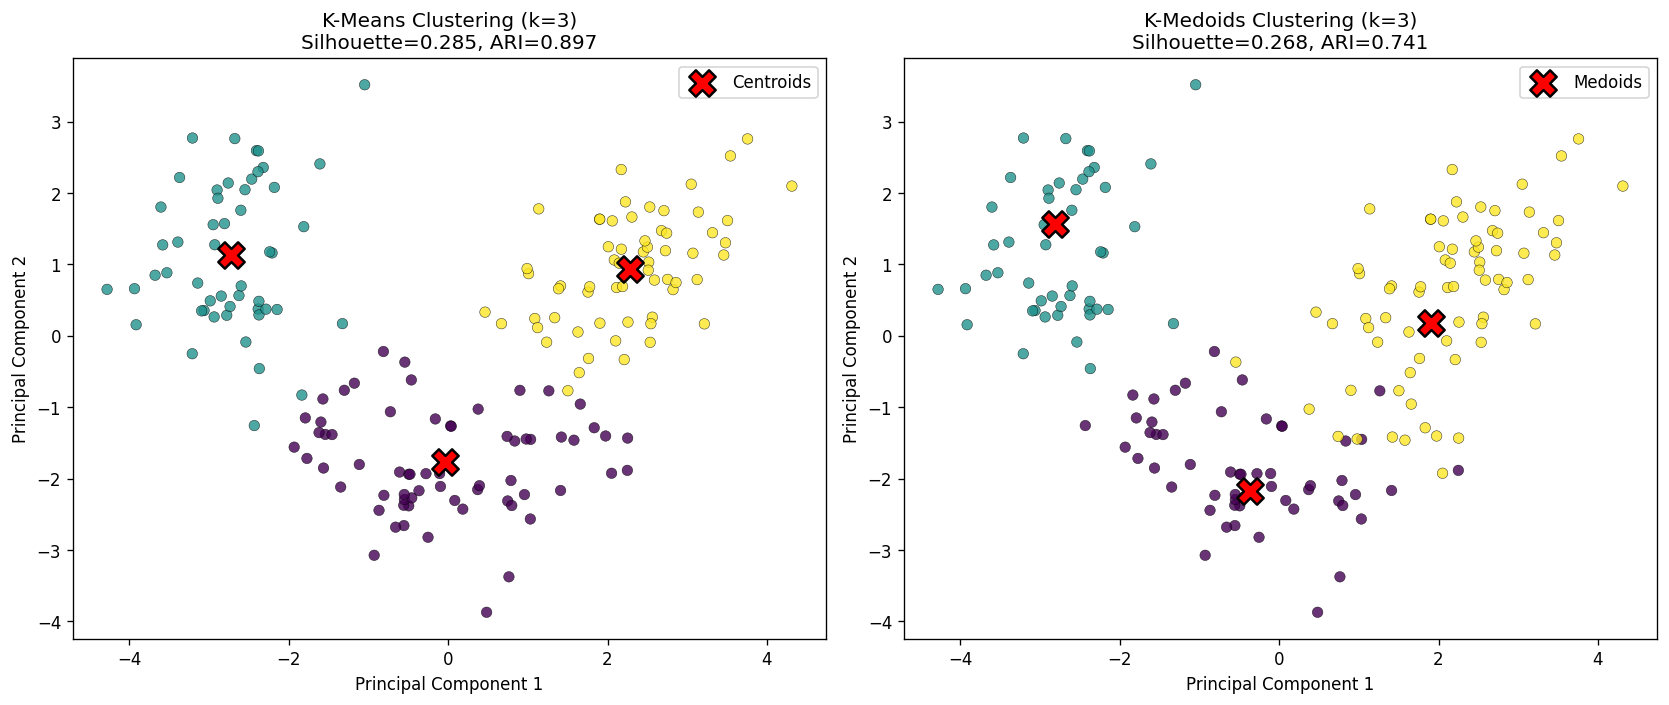

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap="viridis",
                s=40, alpha=0.8, edgecolor="k", linewidth=0.3)
axes[0].scatter(kmeans_centers_pca[:, 0], kmeans_centers_pca[:, 1], c="red",
                marker="X", s=250, edgecolor="black", linewidth=1.5, label="Centroids")
axes[0].set_title(f"K-Means Clustering (k=3)\nSilhouette={kmeans_sil:.3f}, ARI={kmeans_ari:.3f}")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")
axes[0].legend()

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=kmedoids_labels, cmap="viridis",
                s=40, alpha=0.8, edgecolor="k", linewidth=0.3)
axes[1].scatter(kmedoids_centers_pca[:, 0], kmedoids_centers_pca[:, 1], c="red",
                marker="X", s=250, edgecolor="black", linewidth=1.5, label="Medoids")
axes[1].set_title(f"K-Medoids Clustering (k=3)\nSilhouette={kmedoids_sil:.3f}, ARI={kmedoids_ari:.3f}")
axes[1].set_xlabel("Principal Component 1")
axes[1].set_ylabel("Principal Component 2")
axes[1].legend()

plt.tight_layout()
plt.show()


### Analysis: K-Means vs. K-Medoids

**Which algorithm produced better-defined clusters?**
In this run, **K-Means produced the better-defined clusters**: it achieved a
higher Silhouette Score (~0.28 vs. ~0.27) and a substantially higher
Adjusted Rand Index (~0.90 vs. ~0.74) relative to the true wine cultivar
labels. This means K-Means both formed slightly more internally cohesive,
well-separated clusters and aligned much more closely with the actual wine
classes than K-Medoids did.

**What differences do you observe in cluster shapes or positioning?**
The two scatter plots look qualitatively similar overall (both find three
roughly linearly-separated groups along the same two principal components),
but K-Means's centroids sit closer to the geometric center of each cluster
cloud, since a centroid is the mean of all points in the cluster and can be
any point in feature space. K-Medoids's medoids, by contrast, are always
*actual data points*, so they sit slightly off-center and are pulled toward
denser regions of each cluster. K-Medoids also produced a somewhat noisier
boundary between two of the clusters, which is consistent with its lower
ARI — a few borderline points were assigned to the "wrong" cluster relative
to the true labels.

**When is K-Means or K-Medoids preferable?**
- **K-Means** is preferable when the data is numeric, roughly convex/globular
  in shape, free of extreme outliers, and speed matters — it is
  computationally cheaper (centroid = simple mean) and scales better to
  large datasets, which is reflected in it doing well here since the scaled
  Wine features are continuous and reasonably well-behaved.
- **K-Medoids** is preferable when the data contains **outliers or noise**
  (medoids, being actual data points, are far more robust to outliers than
  means), when the distance metric isn't Euclidean (e.g., Manhattan,
  cosine, or an arbitrary dissimilarity matrix — K-Medoids works with any
  distance measure while K-Means requires Euclidean-like averaging), or
  when **interpretability** matters, since each cluster's medoid is a real,
  inspectable data point rather than an abstract average.

For the Wine dataset specifically, K-Means was the better choice: the
features are numeric and standardized, there are no strong outliers, and
Euclidean distance is a natural metric — exactly the conditions under which
K-Means tends to outperform K-Medoids.